# Alpha draft model experiment

Load normalized Dota 2 drafts, build PyTorch tensors, create the Alpha model, and prepare a train/validation loop.

In [56]:
import importlib
import json
import sys
from pathlib import Path
from html import escape

import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset, random_split

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "scripts").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT))

import scripts.ml.dataset as dataset_module
import scripts.ml.models.alpha as alpha_module

importlib.reload(dataset_module)
importlib.reload(alpha_module)

DatasetMaker = dataset_module.DatasetMaker
AlphaDraftModel = alpha_module.AlphaDraftModel

In [57]:
DATASET_SIZE = 4_800
BATCH_SIZE = 64
VAL_FRACTION = 0.2
SEED = 42

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [58]:
with DatasetMaker(env_file=str(PROJECT_ROOT / ".env")) as dataset:
    matches = dataset.fetch_normalized_match_drafts(DATASET_SIZE)

len(matches), matches[0]

(4800,
 NormalizedMatchDraft(match_id=8801351171, radiant_hero_ids=[86, 138, 74, 137, 131], dire_hero_ids=[54, 108, 123, 40, 39], winner_side=1))

In [59]:
radiant_ids = torch.tensor([match.radiant_hero_ids for match in matches], dtype=torch.long)
dire_ids = torch.tensor([match.dire_hero_ids for match in matches], dtype=torch.long)

# DatasetMaker encodes winner_side as radiant=0, dire=1.
# With these labels, sigmoid(logit) is the model's probability of Dire win.
labels = torch.tensor([match.winner_side for match in matches], dtype=torch.float32)

radiant_ids.shape, dire_ids.shape, labels.shape, labels.float().mean()

(torch.Size([4800, 5]),
 torch.Size([4800, 5]),
 torch.Size([4800]),
 tensor(0.4892))

In [60]:
dataset_tensor = TensorDataset(radiant_ids, dire_ids, labels)

val_size = max(1, int(len(dataset_tensor) * VAL_FRACTION))
train_size = len(dataset_tensor) - val_size

generator = torch.Generator().manual_seed(SEED)
train_dataset, val_dataset = random_split(dataset_tensor, [train_size, val_size], generator=generator)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

len(train_dataset), len(val_dataset)

(3840, 960)

In [61]:
heroes_path = PROJECT_ROOT / "dotaconstants" / "build" / "heroes.json"
heroes = json.loads(heroes_path.read_text(encoding="utf-8"))
num_heroes = max(int(hero["id"]) for hero in heroes.values()) + 1

EMBEDDING_DIM = 5

model = AlphaDraftModel(num_heroes=num_heroes, embedding_dim=EMBEDDING_DIM).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

num_heroes, model

(156,
 AlphaDraftModel(
   (hero_embedding): Embedding(156, 5)
   (classifier): Sequential(
     (0): Linear(in_features=30, out_features=128, bias=True)
     (1): ReLU()
     (2): Dropout(p=0.2, inplace=False)
     (3): Linear(in_features=128, out_features=64, bias=True)
     (4): ReLU()
     (5): Dropout(p=0.1, inplace=False)
     (6): Linear(in_features=64, out_features=1, bias=True)
   )
 ))

In [62]:
batch_radiant_ids, batch_dire_ids, batch_labels = next(iter(train_loader))
batch_radiant_ids = batch_radiant_ids.to(device)
batch_dire_ids = batch_dire_ids.to(device)
batch_labels = batch_labels.to(device)

model.train()
logits = model(batch_radiant_ids, batch_dire_ids)
loss = criterion(logits, batch_labels)
probs = torch.sigmoid(logits)

logits.shape, loss.item(), probs[:5].detach().cpu()

(torch.Size([64]),
 0.7063730955123901,
 tensor([0.3753, 0.4893, 0.5493, 0.3704, 0.4735]))

In [63]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    total_examples = 0

    for radiant_batch, dire_batch, label_batch in loader:
        radiant_batch = radiant_batch.to(device)
        dire_batch = dire_batch.to(device)
        label_batch = label_batch.to(device)

        optimizer.zero_grad(set_to_none=True)
        logits = model(radiant_batch, dire_batch)
        loss = criterion(logits, label_batch)
        loss.backward()
        optimizer.step()

        batch_size = label_batch.size(0)
        total_loss += loss.item() * batch_size
        total_examples += batch_size

    return total_loss / total_examples


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_examples = 0

    for radiant_batch, dire_batch, label_batch in loader:
        radiant_batch = radiant_batch.to(device)
        dire_batch = dire_batch.to(device)
        label_batch = label_batch.to(device)

        logits = model(radiant_batch, dire_batch)
        loss = criterion(logits, label_batch)
        preds = (torch.sigmoid(logits) >= 0.5).float()

        batch_size = label_batch.size(0)
        total_loss += loss.item() * batch_size
        total_correct += (preds == label_batch).sum().item()
        total_examples += batch_size

    return {
        "loss": total_loss / total_examples,
        "accuracy": total_correct / total_examples,
    }

In [64]:
EPOCHS = 10

for epoch in range(1, EPOCHS + 1):
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_metrics = evaluate(model, val_loader, criterion, device)
    print(
        f"epoch={epoch:02d} "
        f"train_loss={train_loss:.4f} "
        f"val_loss={val_metrics['loss']:.4f} "
        f"val_accuracy={val_metrics['accuracy']:.3f}"
    )

epoch=01 train_loss=0.7010 val_loss=0.6941 val_accuracy=0.515
epoch=02 train_loss=0.6904 val_loss=0.6942 val_accuracy=0.527
epoch=03 train_loss=0.6867 val_loss=0.6969 val_accuracy=0.516
epoch=04 train_loss=0.6801 val_loss=0.7009 val_accuracy=0.505
epoch=05 train_loss=0.6754 val_loss=0.7061 val_accuracy=0.504
epoch=06 train_loss=0.6714 val_loss=0.7069 val_accuracy=0.516
epoch=07 train_loss=0.6686 val_loss=0.7095 val_accuracy=0.482
epoch=08 train_loss=0.6617 val_loss=0.7128 val_accuracy=0.492
epoch=09 train_loss=0.6549 val_loss=0.7194 val_accuracy=0.497
epoch=10 train_loss=0.6540 val_loss=0.7268 val_accuracy=0.478


In [65]:
@torch.no_grad()
def confusion_matrix(model, loader, device):
    model.eval()

    tp = tn = fp = fn = 0

    for radiant_batch, dire_batch, label_batch in loader:
        radiant_batch = radiant_batch.to(device)
        dire_batch = dire_batch.to(device)
        label_batch = label_batch.to(device).long()

        logits = model(radiant_batch, dire_batch)
        preds = (torch.sigmoid(logits) >= 0.5).long()

        tp += ((preds == 1) & (label_batch == 1)).sum().item()
        tn += ((preds == 0) & (label_batch == 0)).sum().item()
        fp += ((preds == 1) & (label_batch == 0)).sum().item()
        fn += ((preds == 0) & (label_batch == 1)).sum().item()

    return {
        "true_radiant_pred_radiant": tn,
        "true_radiant_pred_dire": fp,
        "true_dire_pred_radiant": fn,
        "true_dire_pred_dire": tp,
    }

confusion_matrix(model, val_loader, device)

{'true_radiant_pred_radiant': 250,
 'true_radiant_pred_dire': 258,
 'true_dire_pred_radiant': 243,
 'true_dire_pred_dire': 209}

## Hero embedding analysis

Look at the trained hero embedding space: 2D projection, nearest/farthest heroes by cosine similarity, and a small coverage check so rare heroes are easier to distrust.

In [66]:
def hero_display_rows(heroes, embeddings, radiant_ids, dire_ids, labels):
    appearances = torch.bincount(
        torch.cat([radiant_ids.flatten(), dire_ids.flatten()]),
        minlength=embeddings.shape[0],
    ).cpu().numpy()
    wins = np.zeros(embeddings.shape[0], dtype=int)

    for radiant_team, dire_team, winner in zip(radiant_ids.tolist(), dire_ids.tolist(), labels.long().tolist()):
        winning_team = dire_team if winner == 1 else radiant_team
        for hero_id in winning_team:
            wins[hero_id] += 1

    rows = []
    for hero in heroes.values():
        hero_id = int(hero["id"])
        if hero_id >= embeddings.shape[0]:
            continue

        localized_name = hero.get("localized_name") or hero.get("name", str(hero_id))
        hero_key = (hero.get("name") or "").removeprefix("npc_dota_hero_")
        row = {
            "hero_id": hero_id,
            "hero": localized_name,
            "hero_key": hero_key,
            "appearances": int(appearances[hero_id]),
            "wins": int(wins[hero_id]),
            "embedding_norm": float(torch.linalg.vector_norm(embeddings[hero_id]).item()),
        }
        row["win_rate"] = row["wins"] / row["appearances"] if row["appearances"] else None
        rows.append(row)

    return sorted(rows, key=lambda row: row["hero"])


model.eval()
hero_embedding_matrix = model.hero_embedding.weight.detach().cpu()
hero_rows = hero_display_rows(heroes, hero_embedding_matrix, radiant_ids, dire_ids, labels)
valid_hero_ids = np.array([row["hero_id"] for row in hero_rows])
valid_embeddings = hero_embedding_matrix[valid_hero_ids].numpy()

sorted(hero_rows, key=lambda row: row["appearances"], reverse=True)[:20]


[{'hero_id': 64,
  'hero': 'Jakiro',
  'hero_key': 'jakiro',
  'appearances': 1158,
  'wins': 556,
  'embedding_norm': 2.6583073139190674,
  'win_rate': 0.48013816925734026},
 {'hero_id': 100,
  'hero': 'Tusk',
  'hero_key': 'tusk',
  'appearances': 1062,
  'wins': 506,
  'embedding_norm': 1.4698755741119385,
  'win_rate': 0.4764595103578154},
 {'hero_id': 19,
  'hero': 'Tiny',
  'hero_key': 'tiny',
  'appearances': 946,
  'wins': 461,
  'embedding_norm': 2.0443484783172607,
  'win_rate': 0.48731501057082455},
 {'hero_id': 123,
  'hero': 'Hoodwink',
  'hero_key': 'hoodwink',
  'appearances': 929,
  'wins': 489,
  'embedding_norm': 2.0462539196014404,
  'win_rate': 0.5263724434876211},
 {'hero_id': 13,
  'hero': 'Puck',
  'hero_key': 'puck',
  'appearances': 869,
  'wins': 402,
  'embedding_norm': 2.1590123176574707,
  'win_rate': 0.4626006904487917},
 {'hero_id': 106,
  'hero': 'Ember Spirit',
  'hero_key': 'ember_spirit',
  'appearances': 838,
  'wins': 435,
  'embedding_norm': 2.1966

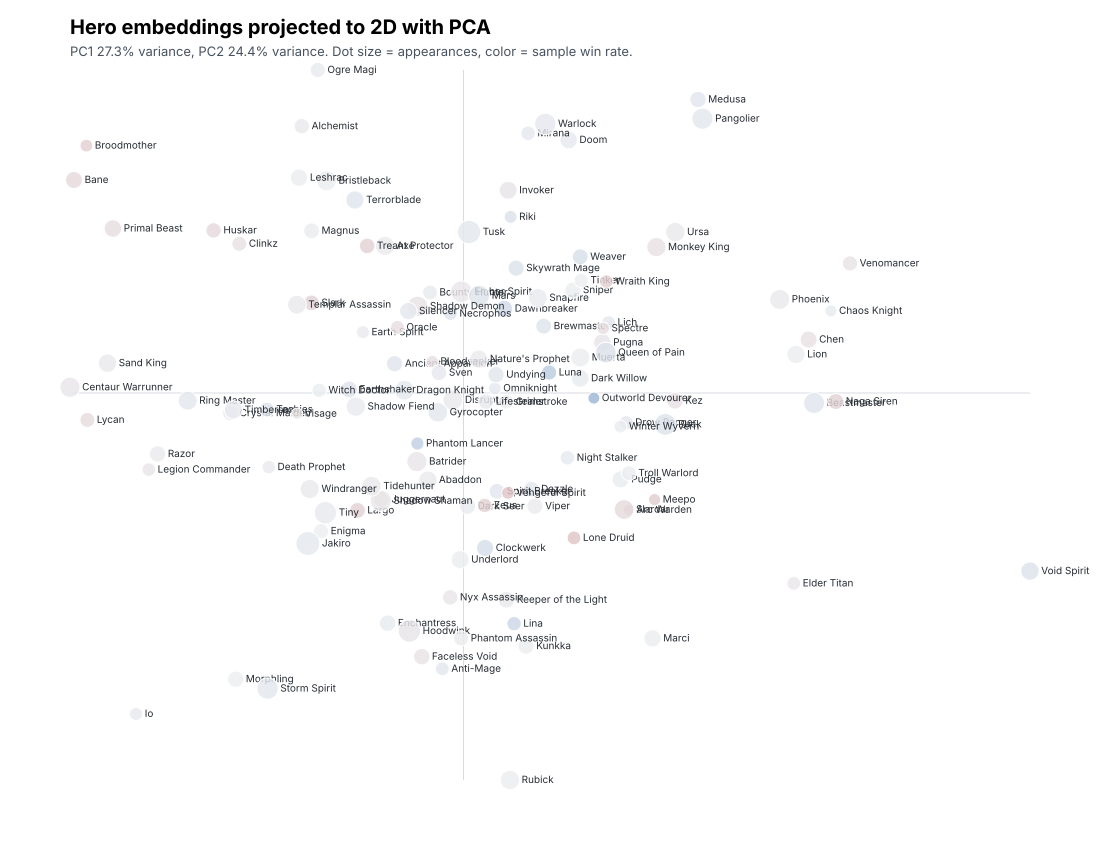

In [67]:
def pca_projection_2d(values):
    centered = values - values.mean(axis=0, keepdims=True)
    _, singular_values, components = np.linalg.svd(centered, full_matrices=False)
    coords = centered @ components[:2].T
    variance = singular_values**2
    explained = variance[:2] / variance.sum()
    return coords, explained


def color_for_win_rate(win_rate):
    if win_rate is None or np.isnan(win_rate):
        return "#8a8f98"
    t = float(np.clip(win_rate, 0.0, 1.0))
    low = np.array([61, 111, 179])
    mid = np.array([235, 237, 240])
    high = np.array([188, 73, 73])
    rgb = low + (mid - low) * (t * 2) if t < 0.5 else mid + (high - mid) * ((t - 0.5) * 2)
    return "#" + "".join(f"{int(channel):02x}" for channel in rgb)


def svg_scatter(rows, explained, *, width=1100, height=850):
    try:
        from IPython.display import SVG
    except ImportError:
        SVG = None

    margin = 70
    xs = np.array([row["x"] for row in rows])
    ys = np.array([row["y"] for row in rows])
    x_span = max(xs.max() - xs.min(), 1e-9)
    y_span = max(ys.max() - ys.min(), 1e-9)

    def sx(value):
        return margin + (value - xs.min()) / x_span * (width - 2 * margin)

    def sy(value):
        return height - margin - (value - ys.min()) / y_span * (height - 2 * margin)

    x0 = sx(0.0) if xs.min() <= 0 <= xs.max() else None
    y0 = sy(0.0) if ys.min() <= 0 <= ys.max() else None
    max_appearances = max(row["appearances"] for row in rows) or 1

    elements = [
        f'<svg xmlns="http://www.w3.org/2000/svg" width="{width}" height="{height}" viewBox="0 0 {width} {height}">',
        '<rect width="100%" height="100%" fill="#ffffff"/>',
        '<style>text{font-family:-apple-system,BlinkMacSystemFont,"Segoe UI",sans-serif}.label{font-size:10px;fill:#252a31}.title{font-size:20px;font-weight:650}.axis{font-size:13px;fill:#47515f}</style>',
        '<text x="70" y="34" class="title">Hero embeddings projected to 2D with PCA</text>',
        f'<text x="70" y="56" class="axis">PC1 {explained[0]:.1%} variance, PC2 {explained[1]:.1%} variance. Dot size = appearances, color = sample win rate.</text>',
    ]
    if x0 is not None:
        elements.append(f'<line x1="{x0:.1f}" y1="{margin}" x2="{x0:.1f}" y2="{height-margin}" stroke="#d7dbe2"/>')
    if y0 is not None:
        elements.append(f'<line x1="{margin}" y1="{y0:.1f}" x2="{width-margin}" y2="{y0:.1f}" stroke="#d7dbe2"/>')

    for row in rows:
        x = sx(row["x"])
        y = sy(row["y"])
        radius = 4 + 8 * np.sqrt(row["appearances"] / max_appearances)
        color = color_for_win_rate(row["win_rate"])
        label = escape(row["hero"])
        elements.append(f'<circle cx="{x:.1f}" cy="{y:.1f}" r="{radius:.1f}" fill="{color}" fill-opacity="0.82" stroke="#ffffff" stroke-width="1"/>')
        elements.append(f'<text x="{x + radius + 2:.1f}" y="{y + 3:.1f}" class="label">{label}</text>')

    elements.append("</svg>")
    svg = "".join(elements)
    return SVG(svg) if SVG else svg


coords, explained = pca_projection_2d(valid_embeddings)
hero_projection = [
    {**row, "x": float(coords[idx, 0]), "y": float(coords[idx, 1])}
    for idx, row in enumerate(hero_rows)
]

svg_scatter(hero_projection, explained)


In [68]:
embedding_norms = np.clip(np.linalg.norm(valid_embeddings, axis=1, keepdims=True), 1e-12, None)
normalized_embeddings = valid_embeddings / embedding_norms
cosine_similarity = normalized_embeddings @ normalized_embeddings.T
hero_names = [row["hero"] for row in hero_rows]


def nearest_heroes(hero_name, top_n=8):
    matches = [idx for idx, row in enumerate(hero_rows) if row["hero"].casefold() == hero_name.casefold()]
    if not matches:
        raise KeyError(f"Unknown hero name: {hero_name!r}")

    row_position = matches[0]
    order = np.argsort(-cosine_similarity[row_position])
    order = [idx for idx in order if idx != row_position][:top_n]
    return [
        {
            "hero": hero_names[idx],
            "cosine_similarity": float(cosine_similarity[row_position, idx]),
            "appearances": hero_rows[idx]["appearances"],
            "win_rate": hero_rows[idx]["win_rate"],
        }
        for idx in order
    ]


nearest_heroes("Pudge")


[{'hero': 'Meepo',
  'cosine_similarity': 0.9651814103126526,
  'appearances': 77,
  'win_rate': 0.5974025974025974},
 {'hero': 'Lone Druid',
  'cosine_similarity': 0.7812302112579346,
  'appearances': 153,
  'win_rate': 0.6209150326797386},
 {'hero': 'Sven',
  'cosine_similarity': 0.7388902902603149,
  'appearances': 279,
  'win_rate': 0.4838709677419355},
 {'hero': 'Clockwerk',
  'cosine_similarity': 0.6762330532073975,
  'appearances': 383,
  'win_rate': 0.44386422976501305},
 {'hero': 'Outworld Devourer',
  'cosine_similarity': 0.6676017642021179,
  'appearances': 71,
  'win_rate': 0.28169014084507044},
 {'hero': 'Omniknight',
  'cosine_similarity': 0.6521740555763245,
  'appearances': 102,
  'win_rate': 0.4803921568627451},
 {'hero': 'Elder Titan',
  'cosine_similarity': 0.6497660875320435,
  'appearances': 152,
  'win_rate': 0.5197368421052632},
 {'hero': 'Vengeful Spirit',
  'cosine_similarity': 0.6331046223640442,
  'appearances': 106,
  'win_rate': 0.6226415094339622}]

In [69]:
def pair_extremes(similarity, hero_names, *, top_n=20):
    upper_i, upper_j = np.triu_indices_from(similarity, k=1)
    pairs = [
        {
            "hero_a": hero_names[idx_a],
            "hero_b": hero_names[idx_b],
            "cosine_similarity": float(similarity[idx_a, idx_b]),
        }
        for idx_a, idx_b in zip(upper_i, upper_j)
    ]
    most_similar = sorted(pairs, key=lambda row: row["cosine_similarity"], reverse=True)[:top_n]
    most_different = sorted(pairs, key=lambda row: row["cosine_similarity"])[:top_n]
    return most_similar, most_different


most_similar_pairs, most_different_pairs = pair_extremes(cosine_similarity, hero_names)
most_similar_pairs


[{'hero_a': 'Keeper of the Light',
  'hero_b': 'Rubick',
  'cosine_similarity': 0.9871148467063904},
 {'hero_a': 'Faceless Void',
  'hero_b': 'Rubick',
  'cosine_similarity': 0.9763304591178894},
 {'hero_a': 'Hoodwink',
  'hero_b': 'Phantom Assassin',
  'cosine_similarity': 0.9747897386550903},
 {'hero_a': 'Huskar',
  'hero_b': 'Primal Beast',
  'cosine_similarity': 0.9737945795059204},
 {'hero_a': 'Pugna',
  'hero_b': 'Queen of Pain',
  'cosine_similarity': 0.9732428193092346},
 {'hero_a': 'Queen of Pain',
  'hero_b': 'Spectre',
  'cosine_similarity': 0.9707241654396057},
 {'hero_a': 'Anti-Mage',
  'hero_b': 'Nyx Assassin',
  'cosine_similarity': 0.9686391353607178},
 {'hero_a': 'Meepo',
  'hero_b': 'Pudge',
  'cosine_similarity': 0.9651814103126526},
 {'hero_a': 'Doom',
  'hero_b': 'Warlock',
  'cosine_similarity': 0.9651374816894531},
 {'hero_a': 'Phoenix',
  'hero_b': 'Venomancer',
  'cosine_similarity': 0.9579693078994751},
 {'hero_a': 'Grimstroke',
  'hero_b': 'Undying',
  'cosin

In [70]:
most_different_pairs


[{'hero_a': 'Hoodwink',
  'hero_b': 'Tusk',
  'cosine_similarity': -0.9856827259063721},
 {'hero_a': 'Io', 'hero_b': 'Ursa', 'cosine_similarity': -0.9829839468002319},
 {'hero_a': 'Clockwerk',
  'hero_b': 'Terrorblade',
  'cosine_similarity': -0.9827606678009033},
 {'hero_a': 'Phantom Assassin',
  'hero_b': 'Tusk',
  'cosine_similarity': -0.9818955063819885},
 {'hero_a': 'Queen of Pain',
  'hero_b': 'Razor',
  'cosine_similarity': -0.979105532169342},
 {'hero_a': 'Grimstroke',
  'hero_b': 'Phantom Lancer',
  'cosine_similarity': -0.9729126691818237},
 {'hero_a': 'Chaos Knight',
  'hero_b': 'Techies',
  'cosine_similarity': -0.9699125289916992},
 {'hero_a': 'Broodmother',
  'hero_b': 'Elder Titan',
  'cosine_similarity': -0.965965986251831},
 {'hero_a': 'Silencer',
  'hero_b': 'Vengeful Spirit',
  'cosine_similarity': -0.9651802778244019},
 {'hero_a': 'Pugna',
  'hero_b': 'Razor',
  'cosine_similarity': -0.9650110006332397},
 {'hero_a': 'Faceless Void',
  'hero_b': 'Mars',
  'cosine_sim

In [71]:
def draft_pair_counts(radiant_ids, dire_ids, num_heroes):
    ally_counts = np.zeros((num_heroes, num_heroes), dtype=int)
    enemy_counts = np.zeros((num_heroes, num_heroes), dtype=int)

    for radiant_team, dire_team in zip(radiant_ids.tolist(), dire_ids.tolist()):
        for team in (radiant_team, dire_team):
            for i, hero_a in enumerate(team):
                for hero_b in team[i + 1:]:
                    ally_counts[hero_a, hero_b] += 1
                    ally_counts[hero_b, hero_a] += 1

        for hero_a in radiant_team:
            for hero_b in dire_team:
                enemy_counts[hero_a, hero_b] += 1
                enemy_counts[hero_b, hero_a] += 1

    return ally_counts, enemy_counts


ally_counts, enemy_counts = draft_pair_counts(radiant_ids, dire_ids, num_heroes)
hero_id_to_position = {hero_id: idx for idx, hero_id in enumerate(valid_hero_ids)}

def frequent_pairs(counts, top_n=15):
    rows = []
    for hero_id_a, hero_id_b in zip(*np.triu_indices_from(counts, k=1)):
        count = counts[hero_id_a, hero_id_b]
        if count == 0 or hero_id_a not in hero_id_to_position or hero_id_b not in hero_id_to_position:
            continue
        pos_a = hero_id_to_position[hero_id_a]
        pos_b = hero_id_to_position[hero_id_b]
        rows.append({
            "hero_a": hero_names[pos_a],
            "hero_b": hero_names[pos_b],
            "draft_count": int(count),
            "embedding_cosine": float(cosine_similarity[pos_a, pos_b]),
        })
    return sorted(rows, key=lambda row: (row["draft_count"], row["embedding_cosine"]), reverse=True)[:top_n]


frequent_ally_pairs = frequent_pairs(ally_counts)
frequent_enemy_pairs = frequent_pairs(enemy_counts)
frequent_ally_pairs


[{'hero_a': 'Tiny',
  'hero_b': 'Jakiro',
  'draft_count': 135,
  'embedding_cosine': 0.34991490840911865},
 {'hero_a': 'Gyrocopter',
  'hero_b': 'Tusk',
  'draft_count': 133,
  'embedding_cosine': -0.021846290677785873},
 {'hero_a': 'Jakiro',
  'hero_b': 'Tusk',
  'draft_count': 131,
  'embedding_cosine': -0.11231019347906113},
 {'hero_a': 'Jakiro',
  'hero_b': 'Centaur Warrunner',
  'draft_count': 122,
  'embedding_cosine': 0.6245244741439819},
 {'hero_a': 'Jakiro',
  'hero_b': 'Mars',
  'draft_count': 122,
  'embedding_cosine': -0.7046775221824646},
 {'hero_a': 'Puck',
  'hero_b': 'Jakiro',
  'draft_count': 119,
  'embedding_cosine': -0.06286647170782089},
 {'hero_a': 'Jakiro',
  'hero_b': 'Ursa',
  'draft_count': 114,
  'embedding_cosine': -0.4676678478717804},
 {'hero_a': 'Jakiro',
  'hero_b': 'Ember Spirit',
  'draft_count': 112,
  'embedding_cosine': 0.2943587601184845},
 {'hero_a': 'Puck',
  'hero_b': 'Tusk',
  'draft_count': 106,
  'embedding_cosine': -0.20802418887615204},
 {

In [72]:
frequent_enemy_pairs


[{'hero_a': 'Warlock',
  'hero_b': 'Jakiro',
  'draft_count': 167,
  'embedding_cosine': -0.7302313446998596},
 {'hero_a': 'Puck',
  'hero_b': 'Void Spirit',
  'draft_count': 156,
  'embedding_cosine': 0.9436421990394592},
 {'hero_a': 'Tiny',
  'hero_b': 'Ember Spirit',
  'draft_count': 145,
  'embedding_cosine': 0.10227838903665543},
 {'hero_a': 'Jakiro',
  'hero_b': 'Tusk',
  'draft_count': 142,
  'embedding_cosine': -0.11231019347906113},
 {'hero_a': 'Jakiro',
  'hero_b': 'Shadow Demon',
  'draft_count': 136,
  'embedding_cosine': -0.08342532813549042},
 {'hero_a': 'Tiny',
  'hero_b': 'Shadow Shaman',
  'draft_count': 132,
  'embedding_cosine': 0.44077008962631226},
 {'hero_a': 'Shadow Shaman',
  'hero_b': 'Jakiro',
  'draft_count': 128,
  'embedding_cosine': 0.36025142669677734},
 {'hero_a': 'Jakiro',
  'hero_b': 'Ring Master',
  'draft_count': 128,
  'embedding_cosine': -0.003485722467303276},
 {'hero_a': 'Storm Spirit',
  'hero_b': 'Jakiro',
  'draft_count': 124,
  'embedding_cos

## Manual draft prediction

In [73]:
def predict_manual_draft(model, radiant_heroes, dire_heroes, *, env_file=str(PROJECT_ROOT / ".env")):
    if len(radiant_heroes) != 5:
        raise ValueError(f"radiant_heroes must contain 5 heroes, got {len(radiant_heroes)}")
    if len(dire_heroes) != 5:
        raise ValueError(f"dire_heroes must contain 5 heroes, got {len(dire_heroes)}")

    with DatasetMaker(env_file=env_file) as dataset:
        radiant_ids = [dataset.hero_name_to_id(hero) for hero in radiant_heroes]
        dire_ids = [dataset.hero_name_to_id(hero) for hero in dire_heroes]

    radiant_tensor = torch.tensor([radiant_ids], dtype=torch.long, device=device)
    dire_tensor = torch.tensor([dire_ids], dtype=torch.long, device=device)

    model.eval()
    with torch.no_grad():
        logit = model(radiant_tensor, dire_tensor).item()
        p_dire = torch.sigmoid(torch.tensor(logit)).item()

    return {
        "radiant_ids": radiant_ids,
        "dire_ids": dire_ids,
        "logit": logit,
        "p_radiant": 1.0 - p_dire,
        "p_dire": p_dire,
        "predicted_winner": "dire" if p_dire >= 0.5 else "radiant",
    }

In [74]:
radiant_heroes = [
    "keeper of the light",
    "axe",
    "phantom assassin",
    "ogre magi",
    "lion",
]

dire_heroes = [
    "bristleback",
    "huskar",
    "phoenix",
    "ember spirit",
    "juggernaut",
]

predict_manual_draft(model, radiant_heroes, dire_heroes)

{'radiant_ids': [90, 2, 44, 84, 26],
 'dire_ids': [99, 59, 110, 106, 8],
 'logit': 0.03464877977967262,
 'p_radiant': 0.49133867025375366,
 'p_dire': 0.5086613297462463,
 'predicted_winner': 'dire'}